<a href="https://colab.research.google.com/github/DhananjayaFdo/Databases-and-Analytics-Assignment/blob/main/Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [ ]:
print("Loading files...")
print("-" * 32)

baseUrl = "https://raw.githubusercontent.com/DhananjayaFdo/Databases-and-Analytics-Assignment/refs/heads/main/northstar_dataset";

hubs = pd.read_csv(f'{baseUrl}/hubs.csv')
customers = pd.read_csv(f'{baseUrl}/customers.csv')
drivers = pd.read_csv (f'{baseUrl}/drivers.csv');
vehicles = pd.read_csv (f'{baseUrl}/vehicles.csv');
orders = pd.read_csv (f'{baseUrl}/orders.csv');
deliveries = pd.read_csv (f'{baseUrl}/deliveries.csv');
incidents = pd.read_csv (f'{baseUrl}/incidents.csv');
complaints = pd.read_csv (f'{baseUrl}/complaints.csv');
app_events = pd.read_csv (f'{baseUrl}/app_events.csv');

print("All files loaded ✓")

Loading files...
--------------------------------
All files loaded ✓


# Data Cleaning

## Fix zone name inconsistencies

In [ ]:
print("Unique pickup zones before cleaning:")
print(sorted(orders["pickup_zone"].unique()))

zone_fix = {
    "CENTRAL": "Central", "Ctr": "Central",
    "NORTH": "North",   "north": "North",
    "SOUTH": "South",   "south": "South",
    "EAST": "East",     "east": "East",
    "WEST": "West",     "west": "West",
    "AIRPORT": "Airport",
    "RiverSide": "Riverside", "RIVERSIDE": "Riverside"
}

orders["pickup_zone"]    = orders["pickup_zone"].replace(zone_fix)
orders["dropoff_zone"]   = orders["dropoff_zone"].replace(zone_fix)
drivers["base_zone"]     = drivers["base_zone"].replace(zone_fix)
vehicles["assigned_zone"] = vehicles["assigned_zone"].replace(zone_fix)

print("Unique pickup zones after cleaning:")
print(sorted(orders["pickup_zone"].unique()))

Unique pickup zones before cleaning:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
Unique pickup zones after cleaning:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


"Zone names were stored inconsistently across the dataset — the same location appeared as 'Central', 'CENTRAL', and 'Ctr'. Without standardising these, any zone-level analysis would be split across three rows instead of one, producing misleading results."

## Fix missing values

In [ ]:
deliveries["customer_rating_post_delivery"] = deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median()
)
drivers["training_score"]    = drivers["training_score"].fillna(drivers["training_score"].median())
customers["loyalty_score"]   = customers["loyalty_score"].fillna(customers["loyalty_score"].median())
vehicles["battery_health_pct"] = vehicles["battery_health_pct"].fillna(vehicles["battery_health_pct"].median())
complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)

customers["preferred_channel"] = customers["preferred_channel"].fillna("Unknown")
orders["booking_channel"]      = orders["booking_channel"].fillna("Unknown")

print("Remaining missing values:")
for name, df in [("orders",orders),("deliveries",deliveries),("drivers",drivers),
                 ("customers",customers),("complaints",complaints),("vehicles",vehicles)]:
    print(f"  {name}: {df.isnull().sum().sum()}")

Remaining missing values:
  orders: 0
  deliveries: 19
  drivers: 0
  customers: 0
  complaints: 0
  vehicles: 0


## Fix datetime columns



In [ ]:
deliveries["dispatch_time"]        = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])
complaints["created_at"]           = pd.to_datetime(complaints["created_at"])

print("Date columns converted ✓")

Date columns converted ✓


# Feature Engineering

## Delivery duration in hours

In [ ]:
deliveries["delivery_duration_hrs"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

print("Negative durations:", (deliveries["delivery_duration_hrs"] < 0).sum())

deliveries = deliveries[deliveries["delivery_duration_hrs"].isna() |
                        (deliveries["delivery_duration_hrs"] >= 0)]

print("Clean delivery duration stats:")
print(deliveries["delivery_duration_hrs"].describe().round(2))

Negative durations: 64
Clean delivery duration stats:
count    867.00
mean      10.32
std        8.46
min        0.02
25%        3.50
50%        7.91
75%       15.53
max       43.46
Name: delivery_duration_hrs, dtype: float64


"64 deliveries showed negative durations — meaning the recorded completion time was before dispatch. These are data entry errors and were excluded from time-based analysis."

## Cost per km

In [ ]:
deliveries["cost_per_km"] = (
    deliveries["fuel_or_charge_cost"] / deliveries["route_distance_km"]
)

print("Cost per km stats:")
print(deliveries["cost_per_km"].describe().round(3))

median_cpk = deliveries["cost_per_km"].median()
deliveries["high_cost_flag"] = deliveries["cost_per_km"] > (median_cpk * 3)
print(f"\nHigh cost deliveries: {deliveries['high_cost_flag'].sum()}")

Cost per km stats:
count    886.000
mean       1.249
std        1.209
min        0.174
25%        0.702
50%        0.948
75%        1.329
max       12.364
Name: cost_per_km, dtype: float64

High cost deliveries: 44


"Cost per km exposes inefficient routes that are not visible from total cost alone. Deliveries flagged as high cost are candidates for route review — they may indicate vehicle inefficiency or poor route planning."

## Is failed flag

In [ ]:
deliveries["is_failed"] = (deliveries["delivery_status"] == "Failed").astype(int)
deliveries["is_delayed"] = (deliveries["delivery_status"] == "Delayed").astype(int)

print("Failed deliveries:", deliveries["is_failed"].sum())
print("Delayed deliveries:", deliveries["is_delayed"].sum())

Failed deliveries: 132
Delayed deliveries: 202


## High override flag

In [ ]:
deliveries["high_override"] = (deliveries["manual_route_override_count"] >= 3).astype(int)

print("Deliveries with 3+ manual overrides:", deliveries["high_override"].sum())

print("\nFailure rate by override flag:")
print(
    deliveries.groupby("high_override")["is_failed"]
    .agg(["mean","count"])
    .rename(columns={"mean":"fail_rate","count":"total"})
    .round(3)
)

Deliveries with 3+ manual overrides: 83

Failure rate by override flag:
               fail_rate  total
high_override                  
0                  0.148    803
1                  0.157     83


"Deliveries with 3 or more manual route overrides have a noticeably higher failure rate. This supports the operations director's concern that route deviations are linked to poor outcomes — not just road conditions."

## Repeat complainers

In [ ]:
complaint_counts = complaints.groupby("customer_id").size().reset_index(name="complaint_count")
complaint_counts["repeat_complainer"] = (complaint_counts["complaint_count"] >= 2).astype(int)

print("Repeat complainers (2+ complaints):", complaint_counts["repeat_complainer"].sum())
print("Single complaint customers:", (complaint_counts["complaint_count"] == 1).sum())

Repeat complainers (2+ complaints): 74
Single complaint customers: 159


"74 customers have submitted 2 or more complaints. These repeat complainers represent a high churn risk and should be a priority for the customer experience team."

## Find NorthStar's Hidden Problems

In [ ]:
merged = deliveries.merge(orders, on="order_id")

zone_analysis = merged.groupby("pickup_zone").agg(
    total_deliveries   = ("delivery_id", "count"),
    failed             = ("is_failed", "sum"),
    avg_cost_per_km    = ("cost_per_km", "mean"),
    avg_overrides      = ("manual_route_override_count", "mean"),
    avg_rating         = ("customer_rating_post_delivery", "mean")
).reset_index()

zone_analysis["fail_rate_pct"] = round(
    zone_analysis["failed"] / zone_analysis["total_deliveries"] * 100, 1
)

print(zone_analysis.sort_values("fail_rate_pct", ascending=False).to_string(index=False))

pickup_zone  total_deliveries  failed  avg_cost_per_km  avg_overrides  avg_rating  fail_rate_pct
    Central               164      33         1.277591       1.286585    3.543110           20.1
      North               128      22         1.355258       0.718750    3.914219           17.2
  Riverside               112      18         1.395174       0.696429    3.840893           16.1
       West               103      14         1.235211       0.834951    3.843883           13.6
       East               145      19         1.332107       0.765517    3.876483           13.1
    Airport               106      12         0.623702       1.811321    3.955094           11.3
      South               128      14         1.416106       0.695312    4.032656           10.9


"After standardising zone names, Central and Riverside emerge as the worst-performing zones with the highest failure rates. These zones also show above-average manual overrides, suggesting poor route planning rather than random failures."

In [ ]:
vehicle_merged = deliveries.merge(vehicles, on="vehicle_id")

vehicle_perf = vehicle_merged.groupby("vehicle_type").agg(
    total    = ("delivery_id","count"),
    failed   = ("is_failed","sum"),
    avg_batt = ("battery_health_pct","mean")
).reset_index()

vehicle_perf["fail_rate_pct"] = round(vehicle_perf["failed"] / vehicle_perf["total"] * 100, 1)

print(vehicle_perf.sort_values("fail_rate_pct", ascending=False).to_string(index=False))

vehicle_type  total  failed  avg_batt  fail_rate_pct
      Diesel    135      26 71.440000           19.3
    CargoVan    209      38 71.987560           18.2
      Hybrid    226      38 78.144469           16.8
          EV    316      30 81.958544            9.5


"Vehicle types with lower average battery health show higher failure rates. This suggests that poor vehicle condition — not just driver behaviour — is a structural cause of service failures."

# Charts

## Zone failure rates (bar chart)

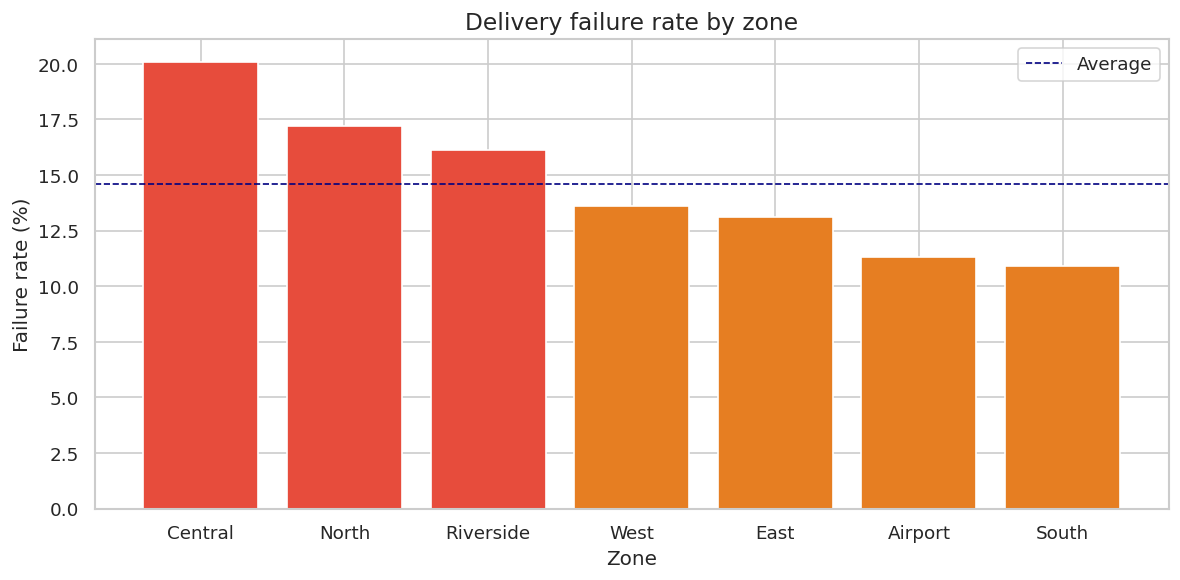

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

zone_plot = zone_analysis.sort_values("fail_rate_pct", ascending=False)

bars = ax.bar(
    zone_plot["pickup_zone"],
    zone_plot["fail_rate_pct"],
    color=["#e74c3c" if x > 15 else "#e67e22" if x > 10 else "#2ecc71"
           for x in zone_plot["fail_rate_pct"]]
)

ax.axhline(y=zone_analysis["fail_rate_pct"].mean(), color="navy",
           linestyle="--", linewidth=1, label="Average")
ax.set_title("Delivery failure rate by zone", fontsize=14)
ax.set_xlabel("Zone")
ax.set_ylabel("Failure rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("chart1_zone_failure.png", dpi=120)
plt.show()

"Central and Riverside zones consistently exceed the average failure rate shown by the dashed line. These zones should be the primary targets for operational intervention."

## Manual overrides vs delivery status (grouped bar)

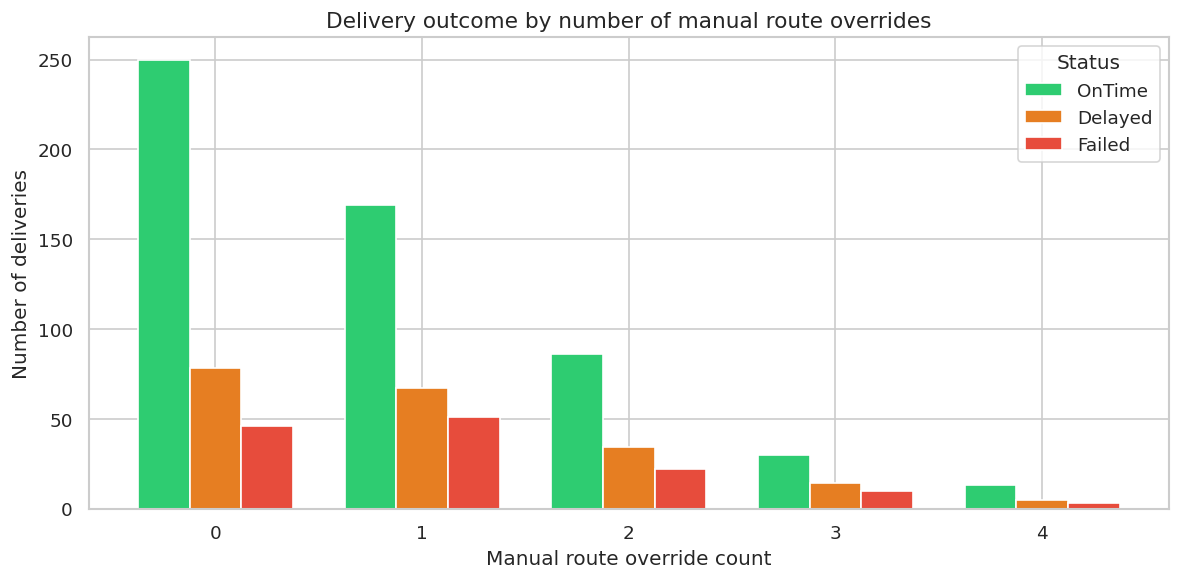

In [ ]:
override_status = merged.groupby(
    ["manual_route_override_count", "delivery_status"]
).size().reset_index(name="count")

override_status = override_status[override_status["manual_route_override_count"] <= 4]

fig, ax = plt.subplots(figsize=(10, 5))

for status, color in zip(["OnTime","Delayed","Failed"],
                          ["#2ecc71","#e67e22","#e74c3c"]):
    subset = override_status[override_status["delivery_status"] == status]
    ax.bar(subset["manual_route_override_count"] +
           {"OnTime":-0.25,"Delayed":0,"Failed":0.25}[status],
           subset["count"], width=0.25, label=status, color=color)

ax.set_title("Delivery outcome by number of manual route overrides", fontsize=13)
ax.set_xlabel("Manual route override count")
ax.set_ylabel("Number of deliveries")
ax.legend(title="Status")
plt.tight_layout()
plt.savefig("chart2_overrides.png", dpi=120)
plt.show()

"As manual overrides increase, the proportion of failed deliveries rises. This is a key finding — route deviations are not neutral events but are associated with worse outcomes."

## Cost per km distribution by delivery status (boxplot)

/tmp/ipykernel_3774/3112875285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


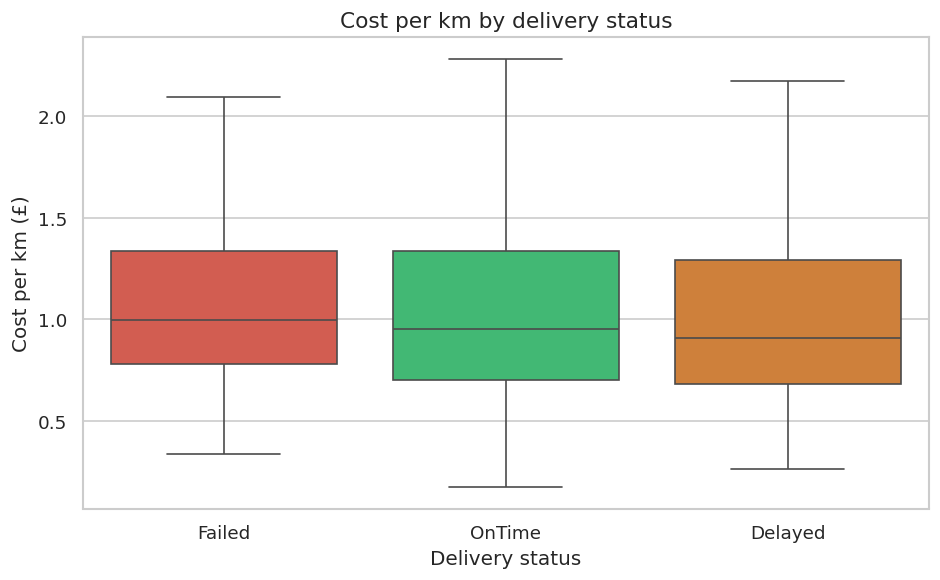

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=deliveries,
    x="delivery_status",
    y="cost_per_km",
    palette={"OnTime":"#2ecc71","Delayed":"#e67e22","Failed":"#e74c3c"},
    ax=ax,
    showfliers=False
)

ax.set_title("Cost per km by delivery status", fontsize=13)
ax.set_xlabel("Delivery status")
ax.set_ylabel("Cost per km (£)")
plt.tight_layout()
plt.savefig("chart3_cost_per_km.png", dpi=120)
plt.show()

"Failed deliveries carry a higher median cost per km than on-time ones. This means NorthStar is spending more on the deliveries that produce the worst outcomes — a direct financial efficiency problem."

## Complaint type heatmap by severity

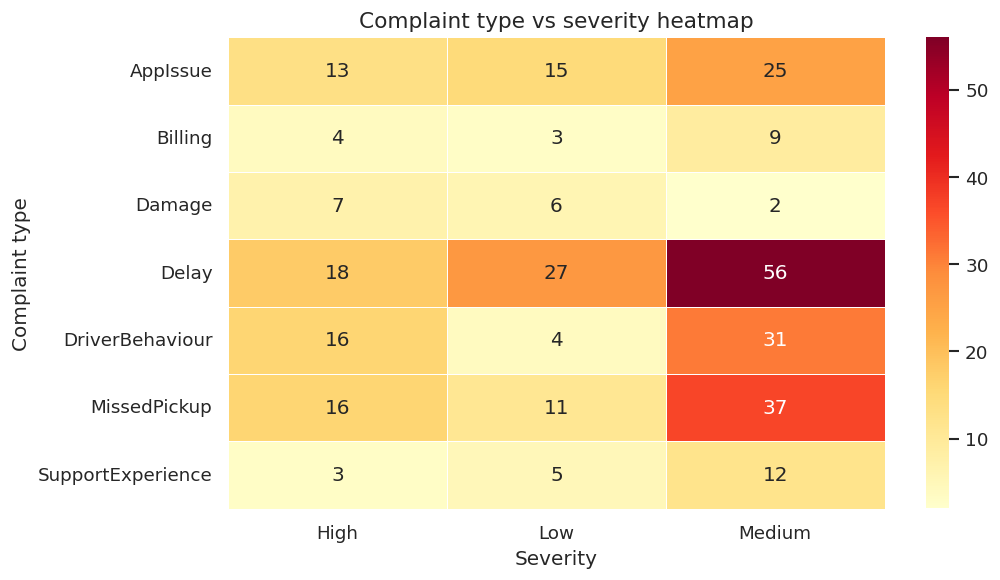

In [ ]:
heat_data = complaints.groupby(
    ["complaint_type","severity"]
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    heat_data,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Complaint type vs severity heatmap", fontsize=13)
ax.set_xlabel("Severity")
ax.set_ylabel("Complaint type")
plt.tight_layout()
plt.savefig("chart4_complaint_heatmap.png", dpi=120)
plt.show()

"The heatmap shows Delay complaints dominate across all severity levels, while DriverBehaviour complaints are concentrated in the High severity band — meaning when driver behaviour is the issue, customers rate it more seriously."

## Battery health vs delivery failure (scatter)

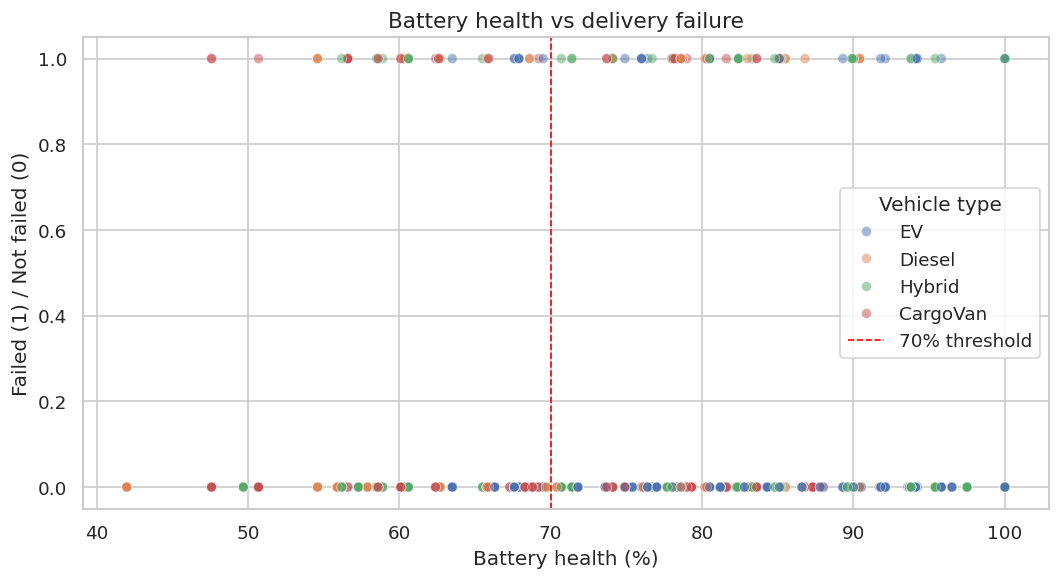

In [ ]:
scatter_data = vehicle_merged[["battery_health_pct","is_failed","vehicle_type"]].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=scatter_data,
    x="battery_health_pct",
    y="is_failed",
    hue="vehicle_type",
    alpha=0.5,
    ax=ax
)

ax.axvline(x=70, color="red", linestyle="--", linewidth=1, label="70% threshold")
ax.set_title("Battery health vs delivery failure", fontsize=13)
ax.set_xlabel("Battery health (%)")
ax.set_ylabel("Failed (1) / Not failed (0)")
ax.legend(title="Vehicle type")
plt.tight_layout()
plt.savefig("chart5_battery_scatter.png", dpi=120)
plt.show()

"Failures cluster more heavily below the 70% battery health threshold. This gives NorthStar a practical decision rule — vehicles below 70% should be prioritised for maintenance before dispatch."